### a) Ler o dataset fakeTelegram.BR_2022.csv, o qual está disponível no link a seguir: https://drive.google.com/file/d/1c_hLzk85pYw-huHSnFYZM_gndUsYRDm/view?usp=drive_link


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

file_path = 'fakeTelegram.BR_2022.csv'
df = pd.read_csv(file_path)

### b) Remova os trava-zaps, as linhas repetidas (duplicadas) e textos com menos de 5 palavras. 

In [16]:
df = df[df['trava_zap'] == False]

# 2. Remover Duplicadas
df = df.drop_duplicates()

# 3. Remover Textos com Menos de 5 Palavras
def contar_palavras(texto):
    if isinstance(texto, str):  
        return len(texto.split())
    else:
        return 0  

df['num_palavras'] = df['text_content_anonymous'].apply(contar_palavras)
df = df[df['num_palavras'] >= 5]

# Remover a coluna auxiliar 'num_palavras'
df = df.drop('num_palavras', axis=1)

print(df.head())


          date_message               id_member_anonymous  \
0  2022-10-05 06:25:04  1078cc958f0febe28f4d03207660715f   
1  2022-10-05 06:25:08                               NaN   
2  2022-10-05 06:26:28  92a2d8fd7144074f659d1d29dc3751da   
3  2022-10-05 06:27:28  d60aa38f62b4977426b70944af4aff72   
5  2022-10-05 06:28:30                               NaN   

                 id_group_anonymous                                 media  \
0  12283e08a2eb5789201e105b34489ee7                                   NaN   
1  12283e08a2eb5789201e105b34489ee7                                   NaN   
2  9f2d7394334eb224c061c9740b5748fc                                   NaN   
3  c8f2de56550ed0bf85249608b7ead93d  94dca4cda503100ebfda7ce2bcc060eb.jpg   
5  b52442a5fbc459ae590dca0d215e32f9                                   NaN   

  media_type media_url  has_media  has_media_url  trava_zap  \
0        NaN       NaN      False          False      False   
1        NaN       NaN      False          False  

### c) Agrupe as linhas com postagens iguais ou extremamente semelhantes. Aqui você pode utilizar uma métrica de semelhança de textos. Crie uma variável para representar a quantidade de vezes que a mensagem foi compartilhada. Observe que ao agrupar linhas que possuem a “mesma” postagem (texto), você deve escolher como valor para as variáveis data e hora da postagem, os valores da cópia mais antiga.

In [17]:

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
stopwords_pt = stopwords.words('portuguese')

df_valid = df[df['text_content_anonymous'].notnull()].copy()

df_valid.reset_index(drop=True, inplace=True)

# Vetorização TF-IDF para comparar textos
vectorizer = TfidfVectorizer(stop_words=stopwords_pt)
tfidf_matrix = vectorizer.fit_transform(df_valid['text_content_anonymous'])

# Matriz de similaridade
similarity_matrix = cosine_similarity(tfidf_matrix)

# Agrupar com base em similaridade acima de um 90%
threshold = 0.9
groups = [-1] * len(df_valid)
group_id = 0

for i in range(len(similarity_matrix)):
    if groups[i] == -1:
        groups[i] = group_id
        for j in range(i+1, len(similarity_matrix)):
            if similarity_matrix[i][j] >= threshold:
                groups[j] = group_id
        group_id += 1

df_valid['group_id'] = groups

# Contar quantas mensagens há por grupo
df_grouped = df_valid.sort_values('date_message').groupby('group_id').agg({
    'text_content_anonymous': 'first',
    'date_message': 'first',
    'id_message': 'first',
    'message_type': 'first',
    'score_sentiment': 'first',
    'score_misinformation': 'first',
    'group_id': 'count'  
}).rename(columns={'group_id': 'num_shares'}).reset_index(drop=True)

df_grouped.head()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\wj070\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,text_content_anonymous,date_message,id_message,message_type,score_sentiment,score_misinformation,num_shares
0,Então é Fato Renato o áudio que eu ouvi no wha...,2022-10-05 06:25:04,16385,Texto,0.0000,NaN,1
1,"Saiu no YouTube do presidente a 8 horas atrás,...",2022-10-05 06:25:08,16386,Texto,0.0644,NaN,1
2,"É isso, nossa parte já foi quase toda feita. N...",2022-10-05 06:26:28,16366,Texto,-0.3551,0.157242,1
3,GENTE ACHEI ELES EM UMA SEITA MAÇONÁRICA,2022-10-05 06:27:28,19281,Imagem,0.0000,NaN,1
4,Kķkkkkk to rindo até agora....Quem disse q ia ...,2022-10-05 06:28:30,2735,Texto,0.7003,0.197813,1


#### d) Você pode criar novos atributos numéricos, tais como: quantidade de palavras, quantidade de caracteres etc. 

In [18]:
import string

# Criar os novos atributos
df_grouped['num_palavras'] = df_grouped['text_content_anonymous'].apply(lambda x: len(str(x).split()))
df_grouped['num_caracteres'] = df_grouped['text_content_anonymous'].apply(lambda x: len(str(x)))
df_grouped['num_maiusculas'] = df_grouped['text_content_anonymous'].apply(lambda x: sum(1 for c in str(x) if c.isupper()))
df_grouped['num_pontuacoes'] = df_grouped['text_content_anonymous'].apply(lambda x: sum(1 for c in str(x) if c in string.punctuation))
df_grouped['num_digitos'] = df_grouped['text_content_anonymous'].apply(lambda x: sum(1 for c in str(x) if c.isdigit()))

In [19]:
df_grouped.head()

,text_content_anonymous,date_message,id_message,message_type,score_sentiment,score_misinformation,num_shares,num_palavras,num_caracteres,num_maiusculas,num_pontuacoes,num_digitos
0,Então é Fato Renato o áudio que eu ouvi no wha...,2022-10-05 06:25:04,16385,Texto,0.0000,NaN,1,20,110,5,1,0
1,"Saiu no YouTube do presidente a 8 horas atrás,...",2022-10-05 06:25:08,16386,Texto,0.0644,NaN,1,23,141,5,2,1
2,"É isso, nossa parte já foi quase toda feita. N...",2022-10-05 06:26:28,16366,Texto,-0.3551,0.157242,1,59,350,6,9,1
3,GENTE ACHEI ELES EM UMA SEITA MAÇONÁRICA,2022-10-05 06:27:28,19281,Imagem,0.0000,NaN,1,7,40,34,0,0
4,Kķkkkkk to rindo até agora....Quem disse q ia ...,2022-10-05 06:28:30,2735,Texto,0.7003,0.197813,1,25,133,3,4,0


### L a F

In [28]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# ==================== TEXT CLEANING ====================
def clean_text(text):
    if pd.isna(text):
        return ''
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-zA-ZÀ-ÿ0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ==================== FEATURE ENGINEERING ====================
def extract_features(df, text_column):
    df['n_palavras'] = df[text_column].apply(lambda x: len(str(x).split()))
    df['n_caracteres'] = df[text_column].apply(lambda x: len(str(x)))
    df['n_maiusculas'] = df[text_column].apply(lambda x: sum(1 for c in str(x) if c.isupper()))
    return df

# ==================== NORMALIZAÇÃO ====================
def normalize_features(X, method=None):
    if method == 'zscore':
        return StandardScaler().fit_transform(X)
    elif method == 'minmax':
        return MinMaxScaler().fit_transform(X)
    return X

# ==================== VECTORIZAÇÃO ====================
def vectorize_text(df, text_column, method='tfidf', ngram_range=(1,1)):
    vectorizer = TfidfVectorizer(ngram_range=ngram_range) if method == 'tfidf' else CountVectorizer(ngram_range=ngram_range)
    X_text = vectorizer.fit_transform(df[text_column].fillna(''))
    return X_text, vectorizer

# ==================== VISUALIZAÇÃO ====================
def plot_results(y_true, y_pred, title):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], '--r')
    plt.xlabel('Real')
    plt.ylabel('Previsto')
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ==================== EXPERIMENTO PRINCIPAL ====================
def run_experimentos(df_grouped):
    df = df_grouped.copy()
    df['text_clean'] = df['text_content_anonymous'].apply(clean_text)
    df = extract_features(df, 'text_clean')

    y = df['num_shares'].values
    X_struct = df[['n_palavras', 'n_caracteres', 'n_maiusculas']].values

    modelos = {
        'linear': LinearRegression(),
        'ridge': Ridge(alpha=1.0),
        'lasso': Lasso(alpha=0.1)
    }

    normalizacoes = [None, 'zscore', 'minmax']
    representacoes = ['bow', 'tfidf']

    kf = KFold(n_splits=10, shuffle=True, random_state=42)

    for rep in representacoes:
        X_text, vectorizer = vectorize_text(df, 'text_clean', method=rep, ngram_range=(1, 1))
        for norm in normalizacoes:
            for nome_modelo, modelo in modelos.items():
                X_full = np.hstack([X_text.toarray(), X_struct])
                X_full = normalize_features(X_full, norm)
                
                y_pred = cross_val_predict(modelo, X_full, y, cv=kf)
                rmse = mean_squared_error(y, y_pred) ** 0.5
                r2 = r2_score(y, y_pred)

                descricao = f"Modelo: {nome_modelo.upper()} | Normalização: {norm or 'sem'} | Representação: {rep.upper()}"
                print("="*80)
                print(descricao)
                print(f"RMSE: {rmse:.2f} | R²: {r2:.2f}")
                plot_results(y, y_pred, descricao)





Modelo: LINEAR | Normalização: sem | Representação: BOW
RMSE: 0.85 | R²: -2.51


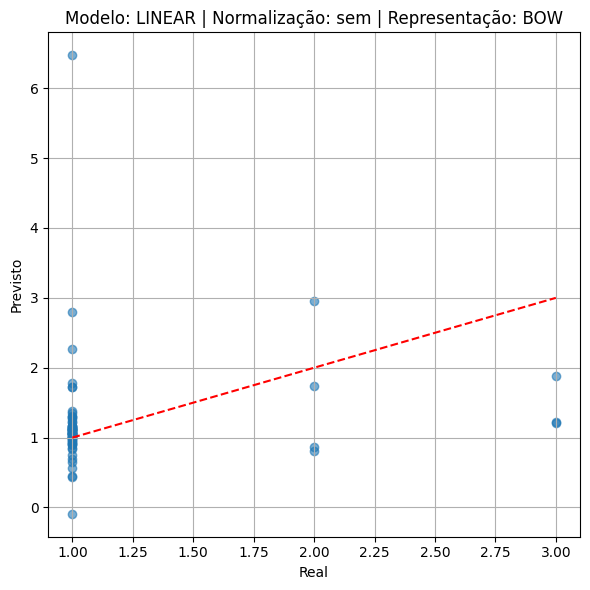

Modelo: RIDGE | Normalização: sem | Representação: BOW
RMSE: 0.81 | R²: -2.11


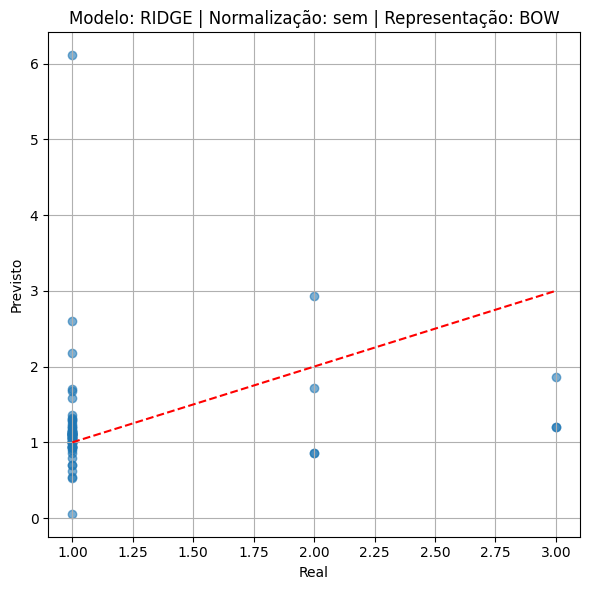

C:\Users\wj070\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.288e-03, tolerance: 1.441e-03
  model = cd_fast.enet_coordinate_descent(
C:\Users\wj070\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.604e-03, tolerance: 1.371e-03
  model = cd_fast.enet_coordinate_descent(
C:\Users\wj070\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

Modelo: LASSO | Normalização: sem | Representação: BOW
RMSE: 0.51 | R²: -0.25


C:\Users\wj070\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.588e-02, tolerance: 1.371e-03
  model = cd_fast.enet_coordinate_descent(
C:\Users\wj070\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.724e-03, tolerance: 1.441e-03
  model = cd_fast.enet_coordinate_descent(
C:\Users\wj070\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

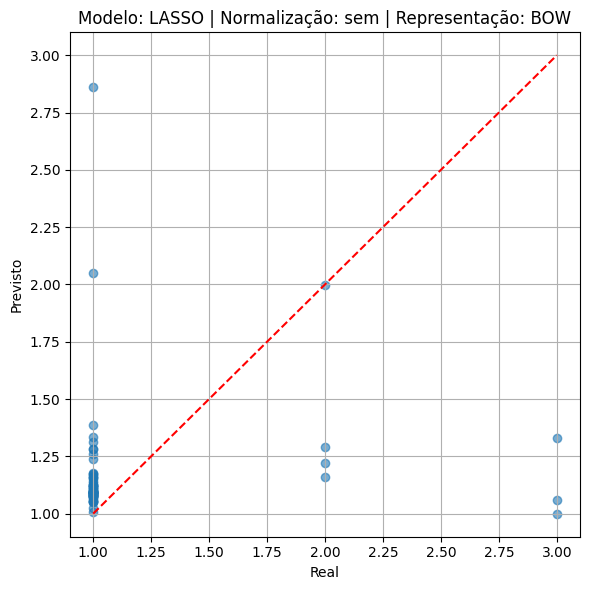

Modelo: LINEAR | Normalização: zscore | Representação: BOW
RMSE: 0.41 | R²: 0.18


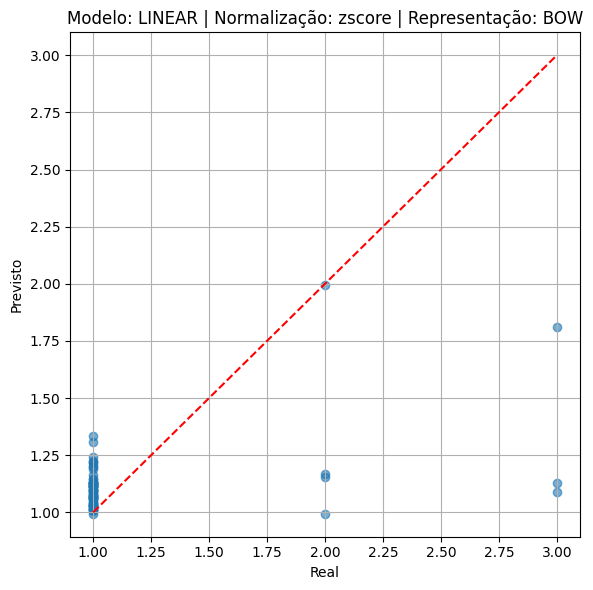

Modelo: RIDGE | Normalização: zscore | Representação: BOW
RMSE: 0.41 | R²: 0.18


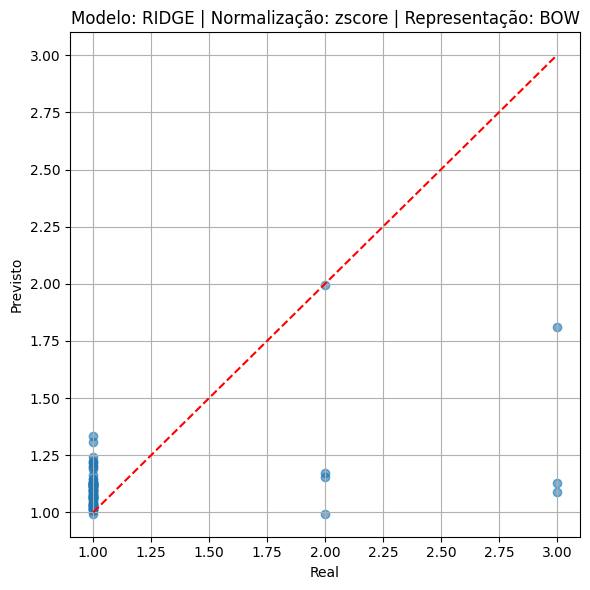

Modelo: LASSO | Normalização: zscore | Representação: BOW
RMSE: 0.44 | R²: 0.07


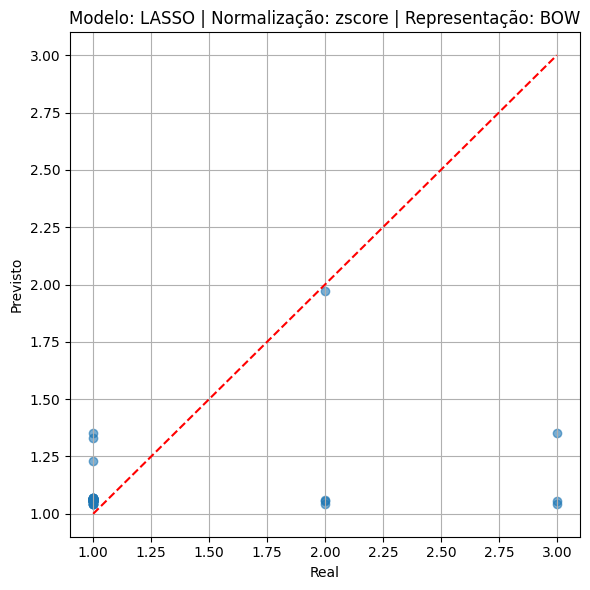

Modelo: LINEAR | Normalização: minmax | Representação: BOW
RMSE: 0.42 | R²: 0.16


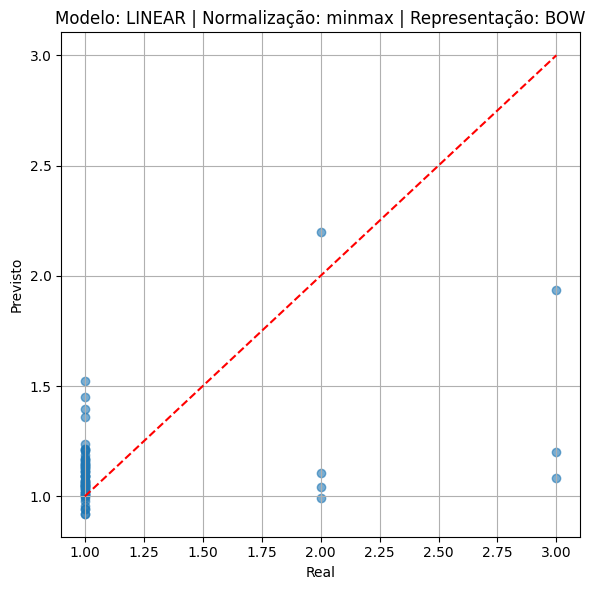

Modelo: RIDGE | Normalização: minmax | Representação: BOW
RMSE: 0.42 | R²: 0.16


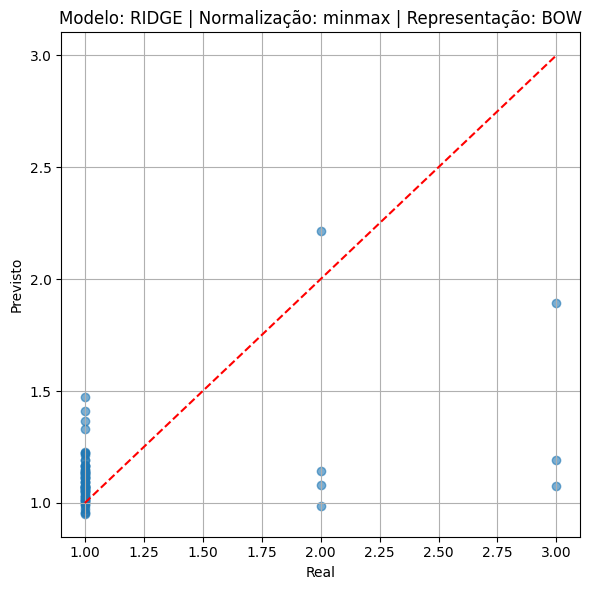

Modelo: LASSO | Normalização: minmax | Representação: BOW
RMSE: 0.46 | R²: -0.02


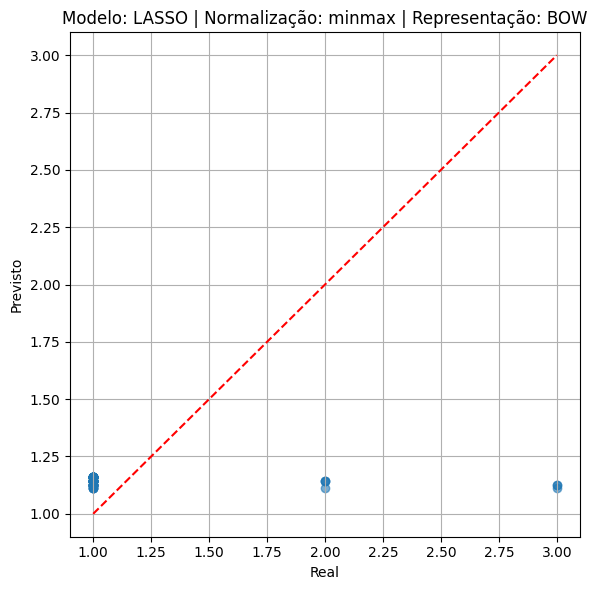

Modelo: LINEAR | Normalização: sem | Representação: TFIDF
RMSE: 0.45 | R²: 0.02


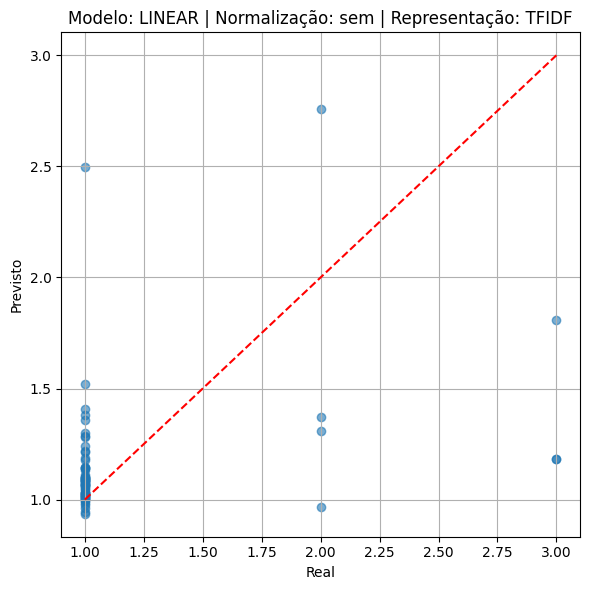

Modelo: RIDGE | Normalização: sem | Representação: TFIDF
RMSE: 0.42 | R²: 0.15


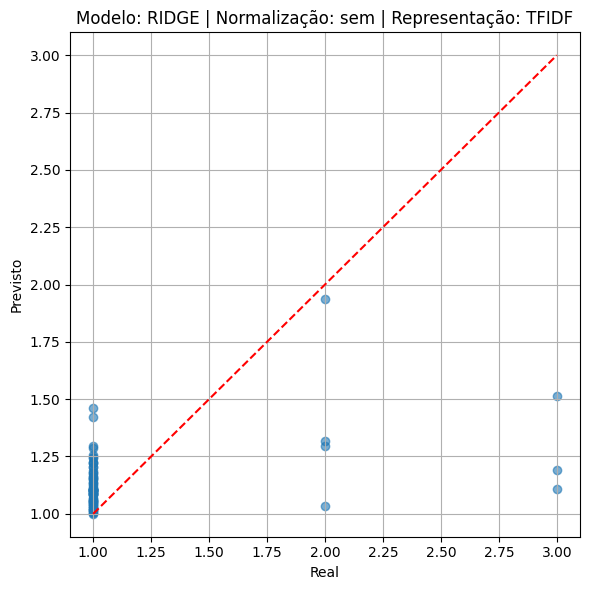

Modelo: LASSO | Normalização: sem | Representação: TFIDF
RMSE: 0.46 | R²: -0.04


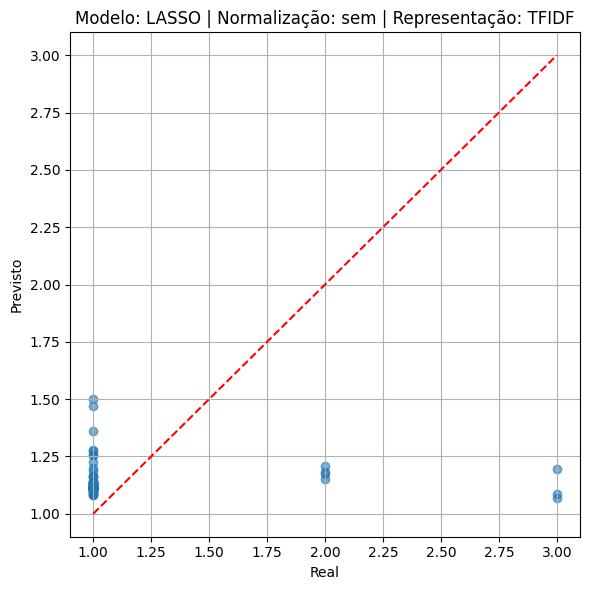

Modelo: LINEAR | Normalização: zscore | Representação: TFIDF
RMSE: 0.41 | R²: 0.19


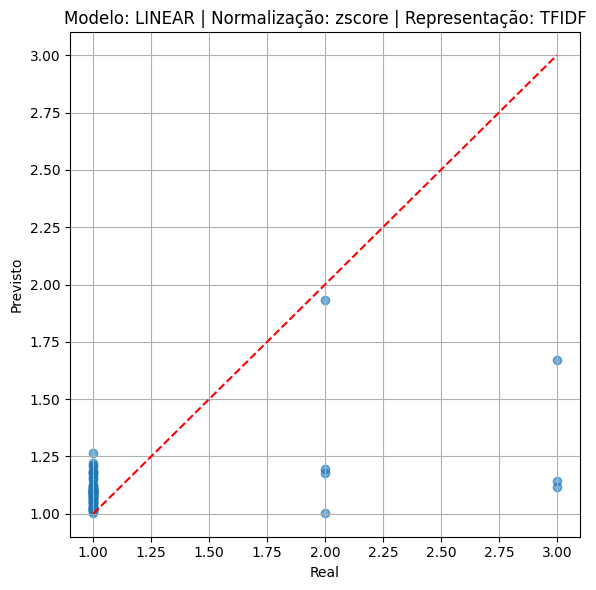

Modelo: RIDGE | Normalização: zscore | Representação: TFIDF
RMSE: 0.41 | R²: 0.19


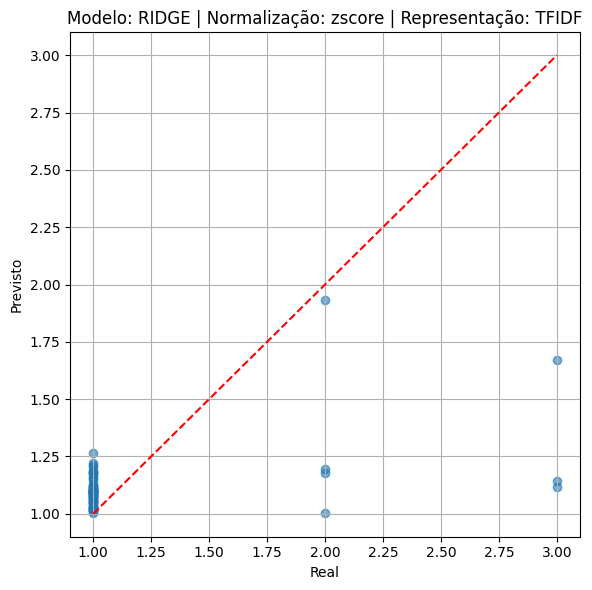

Modelo: LASSO | Normalização: zscore | Representação: TFIDF
RMSE: 0.46 | R²: -0.02


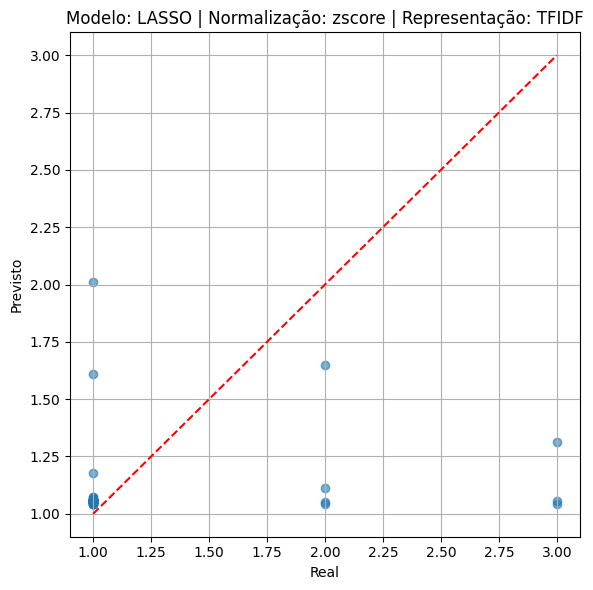

Modelo: LINEAR | Normalização: minmax | Representação: TFIDF
RMSE: 0.40 | R²: 0.22


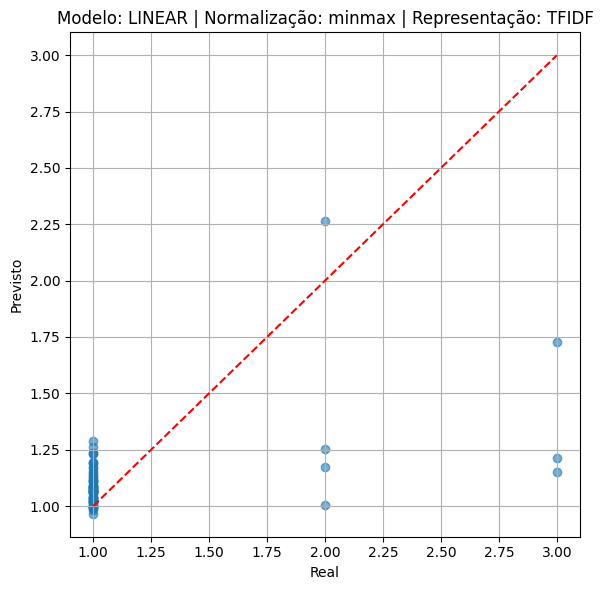

Modelo: RIDGE | Normalização: minmax | Representação: TFIDF
RMSE: 0.40 | R²: 0.22


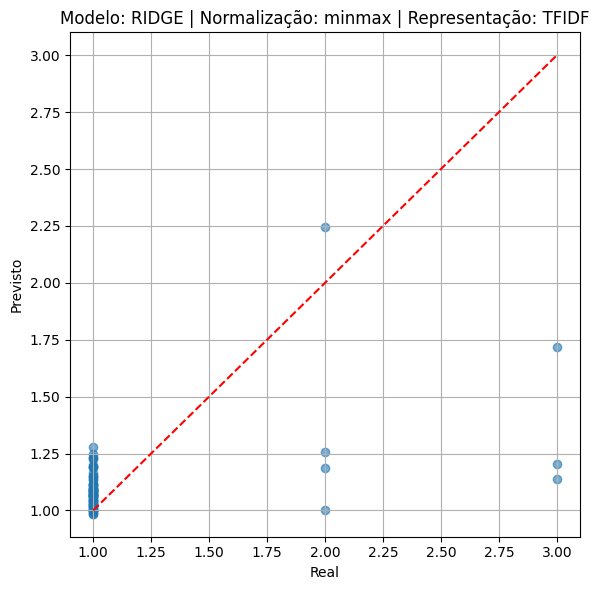

Modelo: LASSO | Normalização: minmax | Representação: TFIDF
RMSE: 0.46 | R²: -0.02


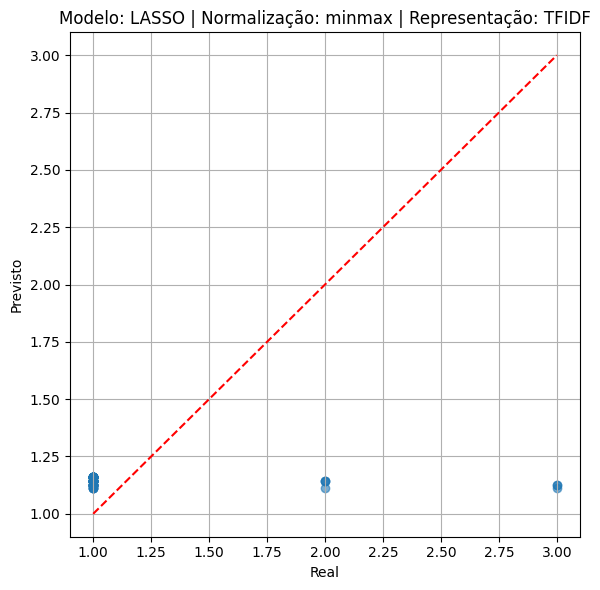

In [29]:
run_experimentos(df_grouped)